 Model Comparison: LogReg vs RF vs XGBoost
 
 **Objective:** Directly compare performance metrics across all three phases to select the final champion model.

In [1]:


# %%
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# Configuration
sns.set_style('whitegrid')



 1. Load Data & Models

In [2]:

# %%
# Load Validation Data
X_val = np.load('../data/processed/X_val.npy')
y_val = np.load('../data/processed/y_val.npy')

# Load Models
logreg = joblib.load('../models/logreg_baseline.joblib')
rf = joblib.load('../models/rf_best.joblib')
xgb_model = joblib.load('../models/xgb_best.joblib')

print("Models loaded successfully.")


Models loaded successfully.


2. Generate Predictions

In [4]:


# %%
models = {
    'Logistic Regression': logreg,
    'Random Forest': rf,
    'XGBoost': xgb_model
}

results = []
roc_data = {}

for name, model in models.items():
    print(f"Evaluating {name}...")
    
    # Predict
    if name == 'Logistic Regression':
        # LogReg was trained on transformed data but pipeline handles it if full pipeline saved
        # If saved model is just the classifier, we need raw data. 
        # Assuming saved model is the classifier and X_val is ALREADY transformed:
        y_pred = model.predict(X_val)
        y_proba = model.predict_proba(X_val)[:, 1]
    else:
        y_pred = model.predict(X_val)
        y_proba = model.predict_proba(X_val)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_proba)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc
    })
    
    # Store ROC curve data
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    roc_data[name] = (fpr, tpr, auc)




Evaluating Logistic Regression...
Evaluating Random Forest...
Evaluating XGBoost...


3. Comparison Table

In [5]:

# %%
results_df = pd.DataFrame(results).set_index('Model')
print("\n=== FINAL MODEL COMPARISON ===")
display(results_df.style.highlight_max(axis=0, color='lightgreen'))

# Save table
results_df.to_csv('../docs/final_model_comparison.csv')



=== FINAL MODEL COMPARISON ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.850962,0.729037,0.600114,0.658323,0.905270
Random Forest,0.832264,0.610084,0.828294,0.702637,0.916564
XGBoost,0.838815,0.617792,0.855676,0.717532,0.928073


4. ROC Curve Championship Plot

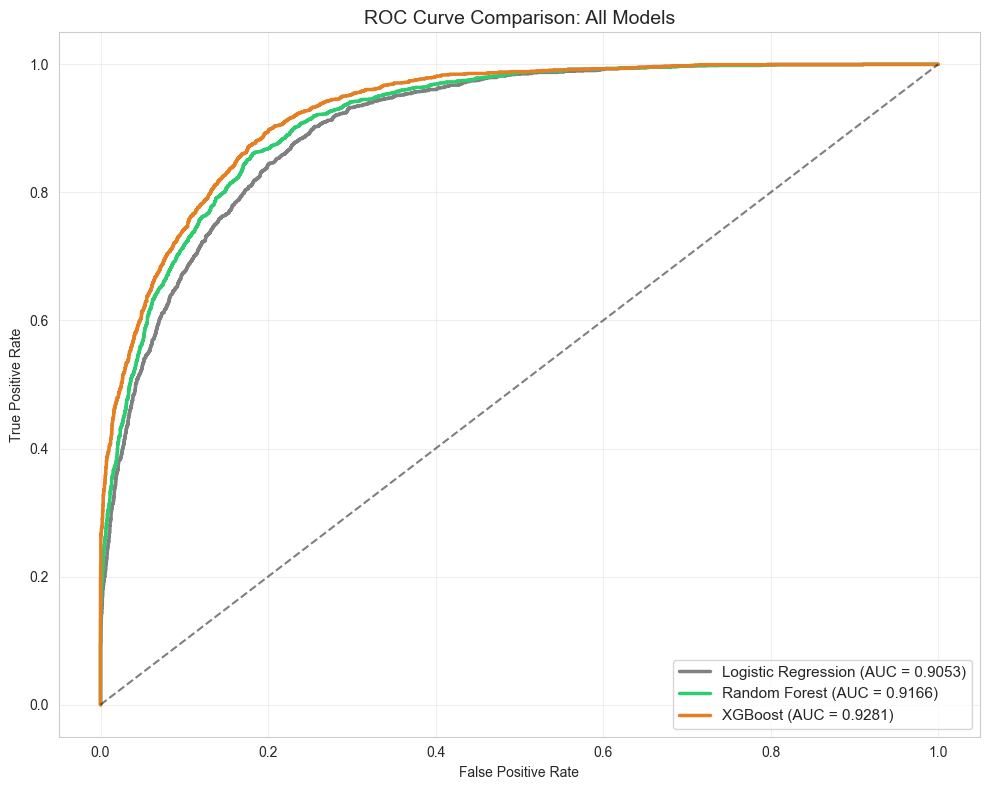

In [6]:

# %%
plt.figure(figsize=(10, 8))

colors = {'Logistic Regression': 'gray', 'Random Forest': '#2ecc71', 'XGBoost': '#e67e22'}

for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', color=colors[name], linewidth=2.5)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: All Models', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../docs/final_roc_comparison.png', dpi=300)
plt.show()



 5. Conclusion
 * **Best Balanced Model:** XGBoost
 * **Best Ranking Model:** XGBoost
 * **Best for Screening (High Recall):** XGBoost